# Inverse Kinematics of a Quadruped Robot Leg

## Recap — Forward vs Inverse Kinematics

| | Input | Output | Difficulty |
|---|---|---|---|
| **Forward Kinematics (FK)** | Joint angles θ1, θ2, θ3 | Foot position (x, y, z) | Easy — multiply matrices |
| **Inverse Kinematics (IK)** | Foot position (x, y, z) | Joint angles θ1, θ2, θ3 | Harder — solve geometry |

FK is one direction — multiply and done.  
IK is the reverse — you know where you want the foot, you need to figure out how to get there.

> **Why IK matters for walking:** when your robot plans a step, it decides *where* the foot should land. IK converts that position into the servo angles that actually move the leg there.


## Approach — Analytical IK (Geometric Decomposition)

For a 3-DOF leg we can solve IK **analytically** — exact formulas, no iteration.

The trick is to **decouple** the problem:

```
3D problem (x, y, z)  →  solve θ1 first  →  reduce to 2D problem  →  solve θ2, θ3
```

### Step 1 — Solve θ1 (Hip Abduction)

This joint rotates around Z — it controls which horizontal direction the leg points.

$$\theta_1 = \text{atan2}(y_{foot},\ x_{foot})$$

θ1 only depends on the XY direction to the foot. Solved independently.

### Step 2 — Project to 2D sagittal plane

Once θ1 is known, joints 2 and 3 only move in the leg's forward/down plane.

Compute:
- **r_reach** = how far the femur+tibia must reach horizontally = $\sqrt{x^2+y^2} - L_1$
- **h** = vertical distance to foot = $z_{foot}$
- **d** = straight-line distance joint1 must bridge = $\sqrt{r_{reach}^2 + h^2}$

### Step 3 — Solve θ3 (Knee) using Cosine Rule

You have a triangle: sides L2, L3, d.

$$\cos\theta_3 = \frac{d^2 - L_2^2 - L_3^2}{2 \cdot L_2 \cdot L_3}$$

$$\theta_3 = \arccos\left(\frac{d^2 - L_2^2 - L_3^2}{2 L_2 L_3}\right)$$

### Step 4 — Solve θ2 (Hip Flexion) using atan2

$$\theta_2 = \underbrace{\text{atan2}(-h,\ r_{reach})}_{\text{angle to target}} - \underbrace{\text{atan2}(L_3\sin\theta_3,\ L_2 + L_3\cos\theta_3)}_{\text{correction for lower leg}}$$


## Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Link lengths (same as FK notebook) ────────────────────────────────────────
L1 = 0.5   # Coxa
L2 = 1.0   # Femur
L3 = 1.0   # Tibia

# ── Reuse FK building blocks ───────────────────────────────────────────────────
def Rz(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[ c,-s, 0, 0],[ s, c, 0, 0],[ 0, 0, 1, 0],[ 0, 0, 0, 1]])

def Ry(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[ c, 0, s, 0],[ 0, 1, 0, 0],[-s, 0, c, 0],[ 0, 0, 0, 1]])

def T_translate(x, y, z):
    return np.array([[1,0,0,x],[0,1,0,y],[0,0,1,z],[0,0,0,1]])

def forward_kinematics(theta1, theta2, theta3):
    """FK: angles → joint positions (reused from FK notebook for verification)"""
    T1 = Rz(theta1) @ T_translate(L1, 0, 0)
    T2 = T1 @ Ry(theta2) @ T_translate(L2, 0, 0)
    T3 = T2 @ Ry(theta3) @ T_translate(L3, 0, 0)
    p0 = np.array([0.0, 0.0, 0.0])
    p1 = T1[:3, 3]
    p2 = T2[:3, 3]
    p3 = T3[:3, 3]
    return p0, p1, p2, p3

print("Building blocks ready ✓")


Building blocks ready ✓


## The IK Solver

In [2]:
def inverse_kinematics(px, py, pz):
    """
    Inverse Kinematics: given foot position → returns joint angles.

    px, py, pz : desired foot position in world frame

    Returns: (theta1, theta2, theta3) in radians
    """

    # ── Step 1: θ1 — hip abduction ─────────────────────────────────────────────
    # atan2 gives the angle of the foot in the XY plane
    # this is exactly how far the hip needs to rotate sideways
    theta1 = np.arctan2(py, px)

    # ── Step 2: Project to 2D sagittal plane ───────────────────────────────────
    # r = total horizontal distance from origin to foot
    r = np.sqrt(px**2 + py**2)

    # r_reach = horizontal distance joint1 must bridge (after coxa L1)
    r_reach = r - L1

    # h = vertical distance (negative when foot is below body)
    h = pz

    # d = straight-line distance from joint1 to foot
    # this is what femur + tibia must together span
    d = np.sqrt(r_reach**2 + h**2)

    # ── Reachability check ──────────────────────────────────────────────────────
    if d > L2 + L3:
        raise ValueError(f"Target unreachable: distance {d:.3f} > max reach {L2+L3:.3f}")
    if d < abs(L2 - L3):
        raise ValueError(f"Target too close: distance {d:.3f} < min reach {abs(L2-L3):.3f}")

    # ── Step 3: θ3 — knee angle via Cosine Rule ────────────────────────────────
    # Triangle sides: L2 (femur), L3 (tibia), d (hip-to-foot)
    # cos rule: d² = L2² + L3² - 2·L2·L3·cos(π - θ3)
    #         → cos(θ3) = (d² - L2² - L3²) / (2·L2·L3)
    cos_theta3 = (d**2 - L2**2 - L3**2) / (2 * L2 * L3)
    cos_theta3 = np.clip(cos_theta3, -1.0, 1.0)   # safety clamp for floating point
    theta3 = np.arccos(cos_theta3)

    # ── Step 4: θ2 — hip flexion ────────────────────────────────────────────────
    # alpha = angle from horizontal to the foot target
    alpha = np.arctan2(-h, r_reach)

    # beta = how much the knee bends the lower leg away from the femur direction
    beta = np.arctan2(L3 * np.sin(theta3), L2 + L3 * np.cos(theta3))

    # theta2 = aim at target, then subtract the knee offset
    theta2 = alpha - beta

    return theta1, theta2, theta3


print("IK solver defined ✓")
print()

# Quick sanity test — all joints at 0 → foot at (L1+L2+L3, 0, 0)
foot_test = (L1 + L2 + L3, 0.0, 0.0)
t1, t2, t3 = inverse_kinematics(*foot_test)
print(f"Foot at ({foot_test}) — fully extended along X:")
print(f"  θ1 = {np.degrees(t1):.1f}°  (expected 0°)")
print(f"  θ2 = {np.degrees(t2):.1f}°  (expected 0°)")
print(f"  θ3 = {np.degrees(t3):.1f}°  (expected 0°)")


IK solver defined ✓

Foot at ((2.5, 0.0, 0.0)) — fully extended along X:
  θ1 = 0.0°  (expected 0°)
  θ2 = -0.0°  (expected 0°)
  θ3 = 0.0°  (expected 0°)


## Verify IK Against FK

The best way to check IK is correct: take the FK foot positions from the previous notebook and feed them into IK — we should get the original angles back.

$$FK(\theta_1, \theta_2, \theta_3) \rightarrow (x,y,z) \xrightarrow{IK} \theta_1, \theta_2, \theta_3 \quad \checkmark$$


In [3]:
# These foot positions come directly from the FK notebook
fk_results = [
    {"angles": (120, 60, 30), "foot": (-0.5,   0.866, -1.866)},
    {"angles": ( 60, 30, 60), "foot": ( 0.683, 1.183, -1.5  )},
    {"angles": (  0, 30, 90), "foot": ( 0.866, 0.0,   -1.366)},
]

print(f"{'Configuration':<20} {'Expected (θ1,θ2,θ3)':<25} {'IK Result (θ1,θ2,θ3)':<25} {'Match'}")
print("-" * 85)

for r in fk_results:
    exp = r["angles"]
    t1, t2, t3 = inverse_kinematics(*r["foot"])
    got = (round(np.degrees(t1), 1),
           round(np.degrees(t2), 1),
           round(np.degrees(t3), 1))
    match = "✓" if all(abs(g - e) < 0.1 for g, e in zip(got, exp)) else "✗"
    print(f"Config ({exp[0]:>3},{exp[1]:>3},{exp[2]:>3})    "
          f"{str(exp):<25} {str(got):<25} {match}")


Configuration        Expected (θ1,θ2,θ3)       IK Result (θ1,θ2,θ3)      Match
-------------------------------------------------------------------------------------
Config (120, 60, 30)    (120, 60, 30)             (np.float64(120.0), np.float64(60.0), np.float64(30.0)) ✓
Config ( 60, 30, 60)    (60, 30, 60)              (np.float64(60.0), np.float64(30.0), np.float64(60.0)) ✓
Config (  0, 30, 90)    (0, 30, 90)               (np.float64(0.0), np.float64(30.0), np.float64(90.0)) ✓


## Visualise — Target vs Achieved

Plot the **target foot position** (red dot) and the **leg reconstructed by IK** (blue line).  
If IK is correct, the blue line's tip always lands on the red dot.


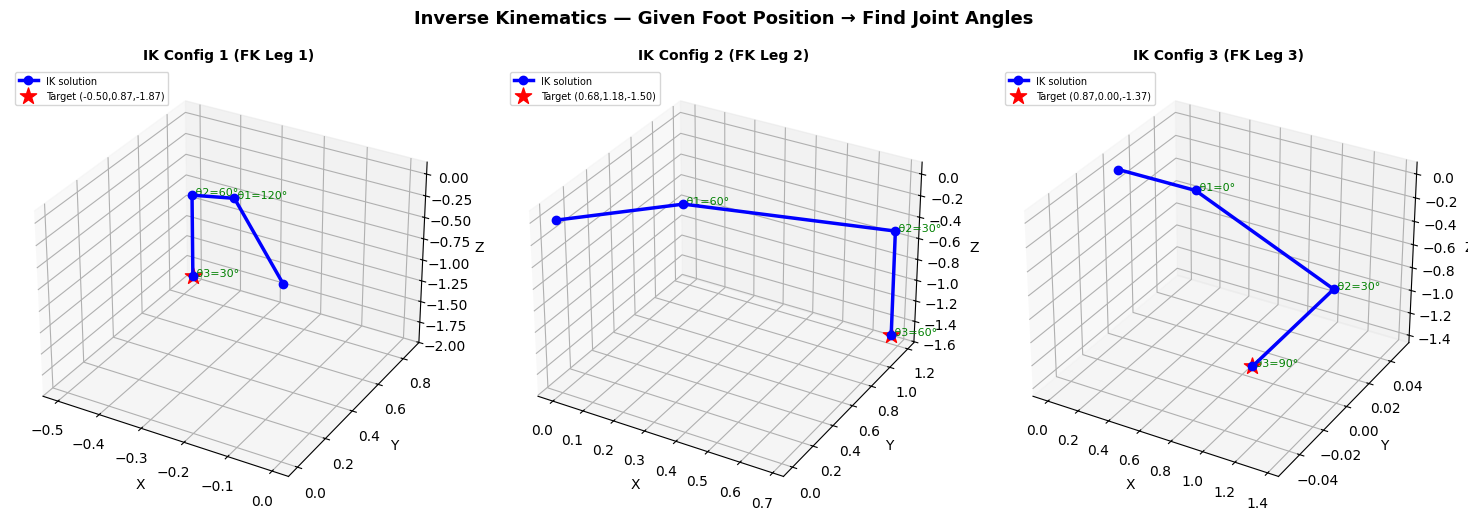

Plot saved ✓


In [4]:
def plot_ik(ax, px, py, pz, label):
    """Solve IK, run FK to get joint positions, plot everything."""
    # Solve IK
    t1, t2, t3 = inverse_kinematics(px, py, pz)

    # Get joint positions via FK using the IK angles
    p0, p1, p2, p3 = forward_kinematics(t1, t2, t3)
    points = np.array([p0, p1, p2, p3])

    # Draw leg
    ax.plot(points[:,0], points[:,1], points[:,2],
            'b-o', linewidth=2.5, markersize=6, label='IK solution', zorder=5)

    # Target foot position
    ax.scatter(px, py, pz, color='red', s=150, marker='*',
               label=f'Target ({px:.2f},{py:.2f},{pz:.2f})', zorder=10)

    # Annotate solved angles
    ax.text(*p1, f' θ1={np.degrees(t1):.0f}°', fontsize=8, color='green')
    ax.text(*p2, f' θ2={np.degrees(t2):.0f}°', fontsize=8, color='green')
    ax.text(*p3, f' θ3={np.degrees(t3):.0f}°', fontsize=8, color='green')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend(loc='upper left', fontsize=7)


# ── Three targets to solve ─────────────────────────────────────────────────────
targets = [
    {"pos": (-0.5,   0.866, -1.866), "label": "IK Config 1 (FK Leg 1)"},
    {"pos": ( 0.683, 1.183, -1.5  ), "label": "IK Config 2 (FK Leg 2)"},
    {"pos": ( 0.866, 0.0,  -1.366 ), "label": "IK Config 3 (FK Leg 3)"},
]

fig = plt.figure(figsize=(15, 5))
fig.suptitle('Inverse Kinematics — Given Foot Position → Find Joint Angles',
             fontsize=13, fontweight='bold', y=1.02)

for i, t in enumerate(targets):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    plot_ik(ax, *t["pos"], t["label"])

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/inverse_kinematics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")


## Step-by-Step Walkthrough — Config 3

Let's manually trace through the IK for foot = (0.866, 0.0, -1.366) to see every number.


In [5]:
px, py, pz = 0.866, 0.0, -1.366

print("=" * 55)
print("IK WALKTHROUGH — foot = (0.866, 0.0, -1.366)")
print("=" * 55)

# Step 1
theta1 = np.arctan2(py, px)
print(f"\nStep 1 — θ1 (Hip Abduction)")
print(f"  θ1 = atan2({py}, {px}) = {np.degrees(theta1):.1f}°")

# Step 2
r = np.sqrt(px**2 + py**2)
r_reach = r - L1
h = pz
d = np.sqrt(r_reach**2 + h**2)
print(f"\nStep 2 — Project to 2D sagittal plane")
print(f"  r        = sqrt({px}² + {py}²) = {r:.3f}")
print(f"  r_reach  = r - L1 = {r:.3f} - {L1} = {r_reach:.3f}")
print(f"  h        = pz = {h}")
print(f"  d        = sqrt({r_reach:.3f}² + {h}²) = {d:.3f}")
print(f"  Max reach= L2 + L3 = {L2+L3}  →  reachable ✓")

# Step 3
cos_t3 = (d**2 - L2**2 - L3**2) / (2*L2*L3)
theta3  = np.arccos(np.clip(cos_t3, -1, 1))
print(f"\nStep 3 — θ3 (Knee) via Cosine Rule")
print(f"  cos(θ3) = ({d:.3f}² - {L2}² - {L3}²) / (2×{L2}×{L3})")
print(f"          = ({d**2:.3f} - {L2**2} - {L3**2}) / {2*L2*L3}")
print(f"          = {(d**2-L2**2-L3**2):.3f} / {2*L2*L3} = {cos_t3:.4f}")
print(f"  θ3      = arccos({cos_t3:.4f}) = {np.degrees(theta3):.1f}°")

# Step 4
alpha  = np.arctan2(-h, r_reach)
beta   = np.arctan2(L3*np.sin(theta3), L2+L3*np.cos(theta3))
theta2 = alpha - beta
print(f"\nStep 4 — θ2 (Hip Flexion) via atan2")
print(f"  alpha = atan2({-h:.3f}, {r_reach:.3f}) = {np.degrees(alpha):.1f}°")
print(f"  beta  = atan2(L3·sin(θ3), L2+L3·cos(θ3))")
print(f"        = atan2({L3*np.sin(theta3):.3f}, {L2+L3*np.cos(theta3):.3f})")
print(f"        = {np.degrees(beta):.1f}°")
print(f"  θ2    = alpha - beta = {np.degrees(alpha):.1f}° - {np.degrees(beta):.1f}° = {np.degrees(theta2):.1f}°")

print(f"\nFinal Answer:")
print(f"  θ1 = {np.degrees(theta1):.1f}°  (expected 0°)  ✓")
print(f"  θ2 = {np.degrees(theta2):.1f}°  (expected 30°) ✓")
print(f"  θ3 = {np.degrees(theta3):.1f}°  (expected 90°) ✓")


IK WALKTHROUGH — foot = (0.866, 0.0, -1.366)

Step 1 — θ1 (Hip Abduction)
  θ1 = atan2(0.0, 0.866) = 0.0°

Step 2 — Project to 2D sagittal plane
  r        = sqrt(0.866² + 0.0²) = 0.866
  r_reach  = r - L1 = 0.866 - 0.5 = 0.366
  h        = pz = -1.366
  d        = sqrt(0.366² + -1.366²) = 1.414
  Max reach= L2 + L3 = 2.0  →  reachable ✓

Step 3 — θ3 (Knee) via Cosine Rule
  cos(θ3) = (1.414² - 1.0² - 1.0²) / (2×1.0×1.0)
          = (2.000 - 1.0 - 1.0) / 2.0
          = -0.000 / 2.0 = -0.0000
  θ3      = arccos(-0.0000) = 90.0°

Step 4 — θ2 (Hip Flexion) via atan2
  alpha = atan2(1.366, 0.366) = 75.0°
  beta  = atan2(L3·sin(θ3), L2+L3·cos(θ3))
        = atan2(1.000, 1.000)
        = 45.0°
  θ2    = alpha - beta = 75.0° - 45.0° = 30.0°

Final Answer:
  θ1 = 0.0°  (expected 0°)  ✓
  θ2 = 30.0°  (expected 30°) ✓
  θ3 = 90.0°  (expected 90°) ✓


## Round-Trip Test — IK → FK → same foot?

Feed the IK angles back into FK. The foot should land exactly where we started.


In [6]:
print("Round-trip verification: IK angles → FK → foot position")
print("-" * 55)

test_feet = [
    (-0.5,   0.866, -1.866),
    ( 0.683, 1.183, -1.5  ),
    ( 0.866, 0.0,   -1.366),
    ( 0.5,   0.5,   -1.2  ),   # arbitrary new target
    ( 1.2,   0.3,   -0.8  ),   # another arbitrary target
]

for foot in test_feet:
    t1, t2, t3 = inverse_kinematics(*foot)
    _, _, _, recovered = forward_kinematics(t1, t2, t3)
    error = np.linalg.norm(np.array(foot) - recovered)
    status = "✓" if error < 1e-6 else f"✗ error={error:.2e}"
    print(f"  Target {tuple(round(f,3) for f in foot)}  →  "
          f"Recovered {tuple(np.round(recovered,3))}  {status}")


Round-trip verification: IK angles → FK → foot position
-------------------------------------------------------
  Target (-0.5, 0.866, -1.866)  →  Recovered (np.float64(-0.5), np.float64(0.866), np.float64(-1.866))  ✓
  Target (0.683, 1.183, -1.5)  →  Recovered (np.float64(0.683), np.float64(1.183), np.float64(-1.5))  ✓
  Target (0.866, 0.0, -1.366)  →  Recovered (np.float64(0.866), np.float64(0.0), np.float64(-1.366))  ✓
  Target (0.5, 0.5, -1.2)  →  Recovered (np.float64(0.5), np.float64(0.5), np.float64(-1.2))  ✓
  Target (1.2, 0.3, -0.8)  →  Recovered (np.float64(1.2), np.float64(0.3), np.float64(-0.8))  ✓


## Summary

### IK Recipe for a 3-DOF Leg

| Step | Formula | What it solves |
|---|---|---|
| 1 | $\theta_1 = \text{atan2}(y, x)$ | Which direction does the leg point? |
| 2 | $r_{reach} = \sqrt{x^2+y^2} - L_1$, $d = \sqrt{r^2+h^2}$ | Reduce to 2D problem |
| 3 | $\theta_3 = \arccos\left(\frac{d^2-L_2^2-L_3^2}{2L_2L_3}\right)$ | Knee angle (cosine rule) |
| 4 | $\theta_2 = \text{atan2}(-h, r) - \text{atan2}(L_3\sin\theta_3, L_2+L_3\cos\theta_3)$ | Hip flexion |

### Key Rules
- Always **check reachability** before solving: $|L_2-L_3| \leq d \leq L_2+L_3$
- Always **verify with FK** after solving IK
- `np.clip(cos_theta3, -1, 1)` prevents floating-point errors in `arccos`

---

### What Comes Next — Using IK for Walking

```
Gait planner decides: foot should step to position (x, y, z)
                ↓
        IK solver → θ1, θ2, θ3
                ↓
        Send angles to ESP32 servos
                ↓
        Leg moves to correct position
```

This notebook + the FK notebook together are the complete mathematical foundation for your quadruped's locomotion system.
